# Step 8 – Exploratory Data Analysis (EDA)

This notebook performs a comprehensive EDA on the three core analysis tables
before formal modelling. The goals are to:

1. **8a** – Assess data quality (dimensions, missing values, data types, outliers)
2. **8b** – Examine univariate distributions and decide on transformations
3. **8c** – Explore bivariate relationships, correlations, and multicollinearity
4. **8d** – Reveal spatial distribution patterns across the global urban system
5. **8e** – Analyse temporal trends in project creation and adoption
6. **8f** – Describe the city collaboration network
7. **8g** – Summarise implications for subsequent modelling steps

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import networkx as nx
from scipy import stats
from pathlib import Path

sns.set_theme(style='whitegrid', context='notebook', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (12, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

DATA = Path('..') / 'data' / 'output'

city_attr   = pd.read_csv(DATA / 'city_attributes.csv')
edges_agg   = pd.read_csv(DATA / 'city_collaboration_edges.csv')
edges_month = pd.read_csv(DATA / 'city_collaboration_edges_monthly.csv')
adoption    = pd.read_csv(DATA / 'city_project_adoption_events.csv')

print(f'city_attributes:              {city_attr.shape}')
print(f'city_collaboration_edges:     {edges_agg.shape}')
print(f'city_collaboration_monthly:   {edges_month.shape}')
print(f'city_project_adoption_events: {adoption.shape}')

city_attributes:              (150, 26)
city_collaboration_edges:     (5118, 4)
city_collaboration_monthly:   (74982, 4)
city_project_adoption_events: (27806, 6)


---
## 8a – Data Quality Check

In [2]:
print('=== city_attributes ===')
print(f'Dimensions: {city_attr.shape[0]} cities × {city_attr.shape[1]} columns')
print(f'Unique countries: {city_attr["country"].nunique()}')
print(f'Unique regions:  {city_attr["region"].nunique()}')
print()

# Data types
numeric_cols = city_attr.select_dtypes(include='number').columns.tolist()
cat_cols = city_attr.select_dtypes(include='object').columns.tolist()
print(f'Numeric columns ({len(numeric_cols)}): {numeric_cols}')
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')
print()

# Missing values
missing = city_attr.isnull().sum()
missing_pct = (missing / len(city_attr) * 100).round(1)
miss_df = pd.DataFrame({'missing': missing, 'pct': missing_pct})
print('Missing values:')
print(miss_df[miss_df['missing'] > 0].to_string())
if miss_df['missing'].sum() == 0:
    print('  No missing values in city_attributes!')
print()

# avg_lag and median_lag have NaN for cities with no adoption events
no_adoption = city_attr[city_attr['adoption_count'] == 0]
print(f'Cities with zero adoption_count (no lag possible): {len(no_adoption)}')

=== city_attributes ===
Dimensions: 150 cities × 26 columns
Unique countries: 43
Unique regions:  9

Numeric columns (23): ['lat', 'lon', 'entity_count', 'origination_count', 'origination_rate', 'adoption_count', 'adoption_rate', 'avg_lag', 'median_lag', 'collaboration_count', 'weighted_degree', 'betweenness', 'eigenvector_centrality', 'population_million', 'gdp_per_capita', 'education_tertiary_pct', 'internet_users_pct', 'rd_expenditure_pct', 'research_capacity', 'timezone_utc', 'origination_rate_pop', 'adoption_rate_pop', 'collaboration_rate_pop']
Categorical columns (3): ['city', 'country', 'region']

Missing values:
            missing   pct
avg_lag          46  30.7
median_lag       46  30.7

Cities with zero adoption_count (no lag possible): 46


In [3]:
# Quality check for other tables
print('=== city_collaboration_edges ===')
print(f'Shape: {edges_agg.shape}')
print(f'Missing: {edges_agg.isnull().sum().sum()}')
print(f'Unique source cities: {edges_agg["source_city"].nunique()}')
print(f'Unique target cities: {edges_agg["target_city"].nunique()}')
all_edge_cities = set(edges_agg['source_city']) | set(edges_agg['target_city'])
print(f'Total unique cities in edges: {len(all_edge_cities)}')
print()

print('=== city_collaboration_edges_monthly ===')
print(f'Shape: {edges_month.shape}')
print(f'Month range: {edges_month["month"].min()} – {edges_month["month"].max()}')
print(f'Unique months: {edges_month["month"].nunique()}')
print()

print('=== city_project_adoption_events ===')
print(f'Shape: {adoption.shape}')
print(f'Unique cities: {adoption["city"].nunique()}')
print(f'Unique projects: {adoption["project_id"].nunique()}')
print(f'Originators (is_originator=1): {adoption["is_originator"].sum()}')
print(f'Non-originator adoptions:      {(adoption["is_originator"]==0).sum()}')
print(f'Lag value distribution:')
print(adoption['lag'].value_counts().sort_index().to_string())

=== city_collaboration_edges ===
Shape: (5118, 4)
Missing: 0
Unique source cities: 102
Unique target cities: 102
Total unique cities in edges: 103

=== city_collaboration_edges_monthly ===
Shape: (74982, 4)
Month range: 202201 – 202512
Unique months: 48

=== city_project_adoption_events ===
Shape: (27806, 6)
Unique cities: 103
Unique projects: 7870
Originators (is_originator=1): 2914
Non-originator adoptions:      24892
Lag value distribution:
lag
0     2914
1    24892


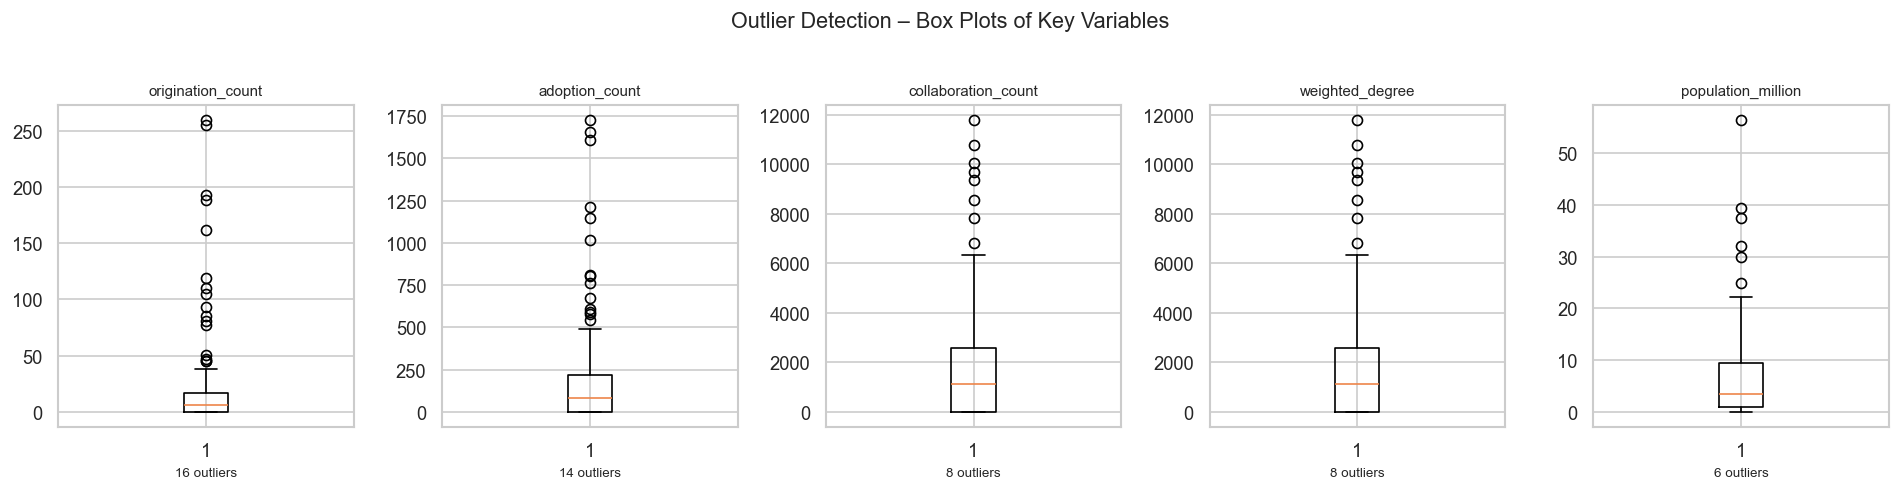

In [4]:
# Outlier detection for key numeric variables
outlier_cols = ['origination_count', 'adoption_count', 'collaboration_count',
                'weighted_degree', 'population_million']

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(16, 4))
for ax, col in zip(axes, outlier_cols):
    data = city_attr[col].dropna()
    ax.boxplot(data, vert=True)
    ax.set_title(col, fontsize=9)
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    n_outliers = ((data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)).sum()
    ax.set_xlabel(f'{n_outliers} outliers', fontsize=8)

fig.suptitle('Outlier Detection – Box Plots of Key Variables', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [5]:
# Descriptive statistics summary table
desc_cols = ['entity_count', 'origination_count', 'adoption_count',
             'avg_lag', 'collaboration_count', 'weighted_degree',
             'betweenness', 'eigenvector_centrality',
             'population_million', 'gdp_per_capita',
             'education_tertiary_pct', 'internet_users_pct',
             'rd_expenditure_pct', 'research_capacity']

city_attr[desc_cols].describe().round(2)

,entity_count,origination_count,adoption_count,avg_lag,collaboration_count,weighted_degree,betweenness,eigenvector_centrality,population_million,gdp_per_capita,education_tertiary_pct,internet_users_pct,rd_expenditure_pct,research_capacity
count,150.00,150.00,150.00,104.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00
mean,14.88,19.63,187.51,0.91,1901.22,1901.22,0.01,0.05,6.80,43807.47,70.91,84.62,2.46,0.81
std,26.57,42.30,304.75,0.07,2399.92,2399.92,0.04,0.06,8.66,29330.96,23.02,14.68,1.13,0.89
min,3.00,0.00,0.00,0.36,0.00,0.00,0.00,0.00,0.02,1020.00,9.00,25.00,0.22,0.00
25%,4.00,0.00,0.00,0.88,0.00,0.00,0.00,0.00,1.02,12720.00,60.00,76.00,1.50,0.00
50%,6.00,6.00,85.00,0.93,1116.50,1116.50,0.00,0.03,3.55,49450.00,74.00,92.00,2.55,1.00
75%,13.00,16.75,215.50,0.94,2600.50,2600.50,0.00,0.07,9.55,76330.00,88.20,93.00,3.46,1.00
max,187.00,260.00,1729.00,0.97,11816.00,11816.00,0.47,0.31,56.50,103685.00,143.00,99.00,5.44,5.00


---
## 8b – Univariate Distributions

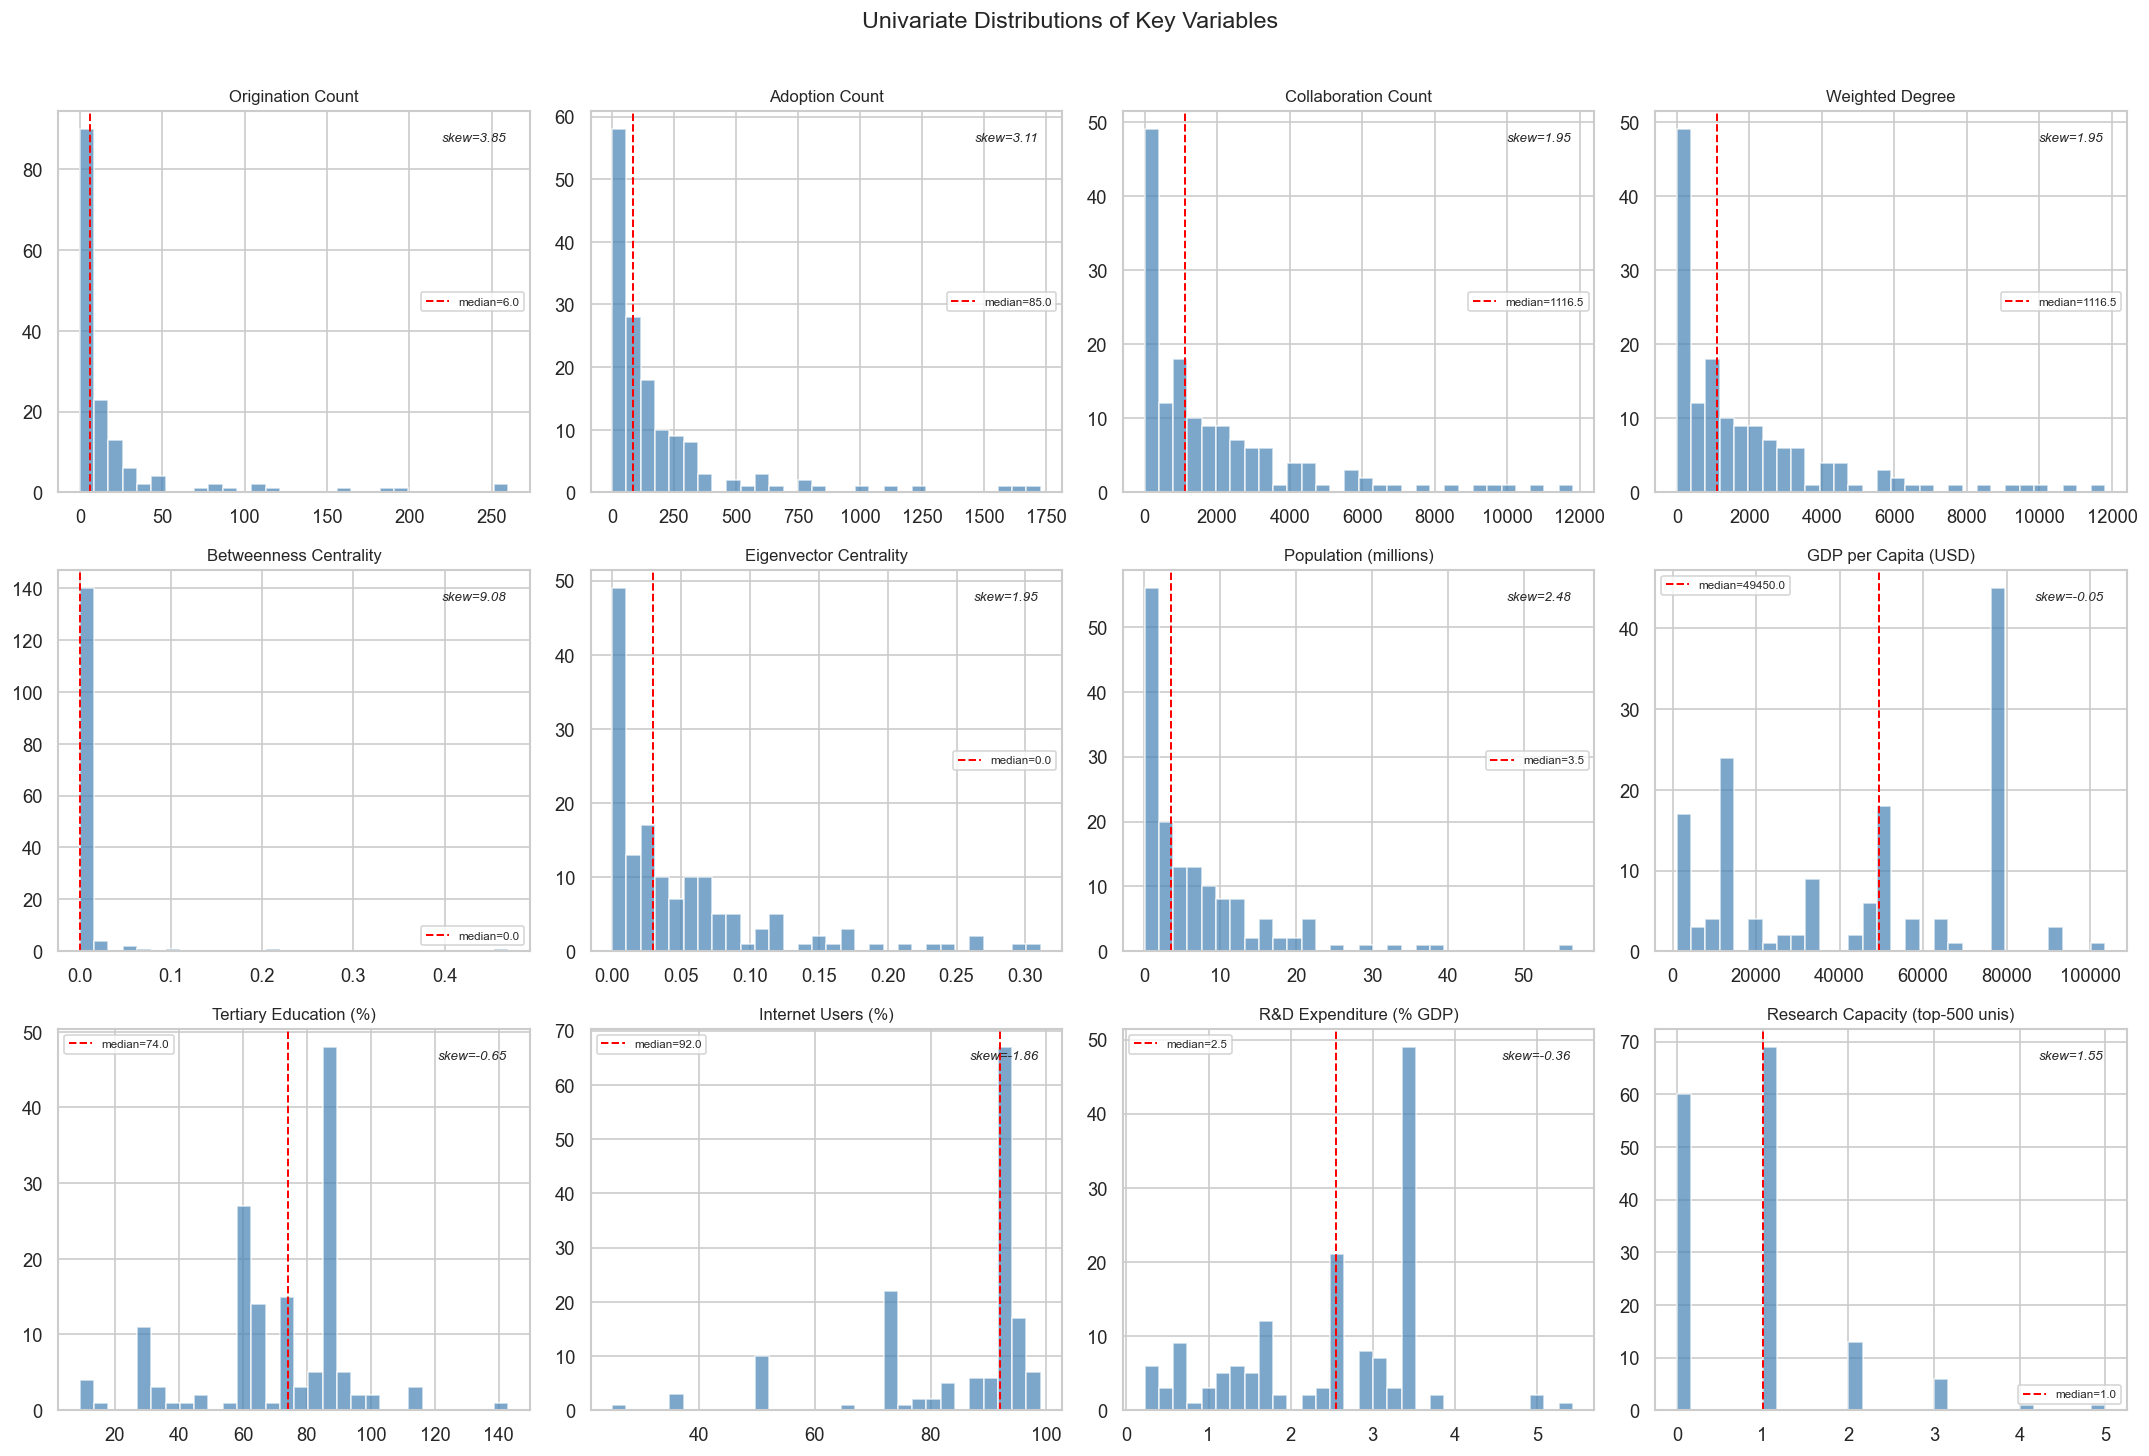

In [6]:
# Histograms / KDE for key numeric variables
hist_vars = [
    ('origination_count', 'Origination Count'),
    ('adoption_count', 'Adoption Count'),
    ('collaboration_count', 'Collaboration Count'),
    ('weighted_degree', 'Weighted Degree'),
    ('betweenness', 'Betweenness Centrality'),
    ('eigenvector_centrality', 'Eigenvector Centrality'),
    ('population_million', 'Population (millions)'),
    ('gdp_per_capita', 'GDP per Capita (USD)'),
    ('education_tertiary_pct', 'Tertiary Education (%)'),
    ('internet_users_pct', 'Internet Users (%)'),
    ('rd_expenditure_pct', 'R&D Expenditure (% GDP)'),
    ('research_capacity', 'Research Capacity (top-500 unis)'),
]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for ax, (col, label) in zip(axes, hist_vars):
    data = city_attr[col].dropna()
    ax.hist(data, bins=30, edgecolor='white', alpha=0.7, color='steelblue')
    ax.axvline(data.median(), color='red', ls='--', lw=1.2, label=f'median={data.median():.1f}')
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=7)
    skew = data.skew()
    ax.text(0.95, 0.92, f'skew={skew:.2f}', transform=ax.transAxes,
            ha='right', fontsize=8, style='italic')

fig.suptitle('Univariate Distributions of Key Variables', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

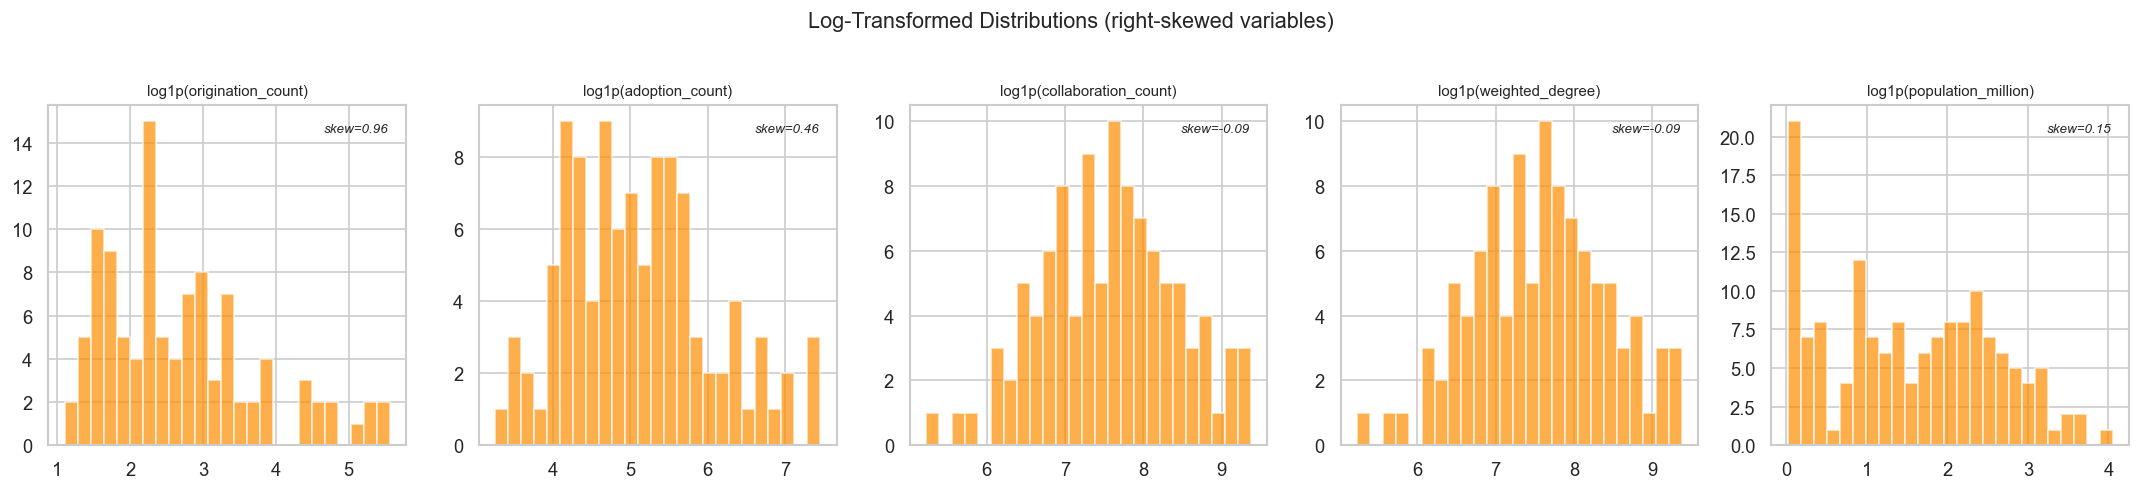


Skewness comparison (raw → log1p):
  origination_count               +3.85 → +0.96
  adoption_count                  +3.11 → +0.46
  collaboration_count             +1.95 → -0.09
  weighted_degree                 +1.95 → -0.09
  population_million              +2.48 → +0.15


In [7]:
# Log-transformed distributions for right-skewed variables
log_vars = ['origination_count', 'adoption_count', 'collaboration_count',
            'weighted_degree', 'population_million']

fig, axes = plt.subplots(1, len(log_vars), figsize=(18, 4))

for ax, col in zip(axes, log_vars):
    data = city_attr[col].dropna()
    data_pos = data[data > 0]
    log_data = np.log1p(data_pos)
    ax.hist(log_data, bins=25, edgecolor='white', alpha=0.7, color='darkorange')
    ax.set_title(f'log1p({col})', fontsize=9)
    skew = log_data.skew()
    ax.text(0.95, 0.92, f'skew={skew:.2f}', transform=ax.transAxes,
            ha='right', fontsize=8, style='italic')

fig.suptitle('Log-Transformed Distributions (right-skewed variables)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('\nSkewness comparison (raw → log1p):')
for col in log_vars:
    raw_skew = city_attr[col].dropna().skew()
    log_skew = np.log1p(city_attr[col].dropna()[city_attr[col]>0]).skew()
    print(f'  {col:30s}  {raw_skew:+.2f} → {log_skew:+.2f}')

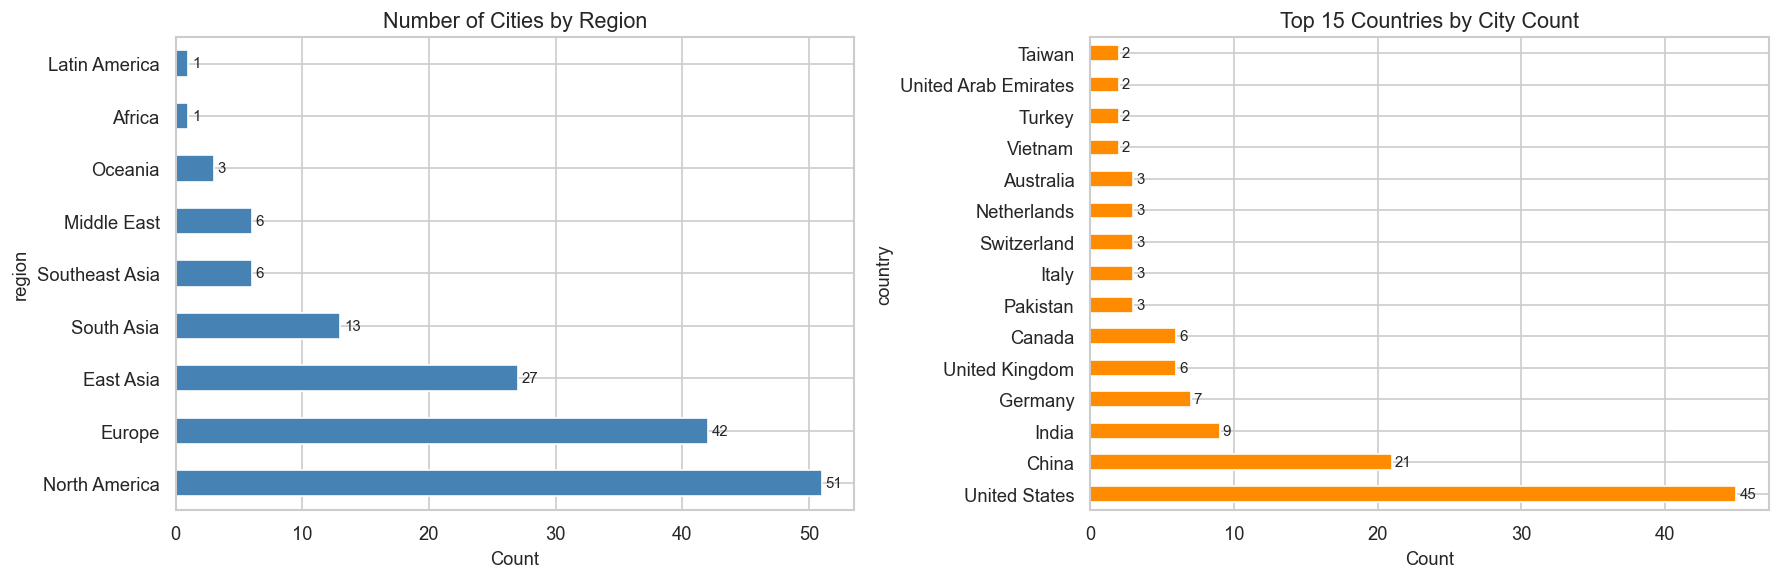

In [8]:
# Categorical variable distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Region
region_counts = city_attr['region'].value_counts()
region_counts.plot.barh(ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Number of Cities by Region')
axes[0].set_xlabel('Count')
for i, v in enumerate(region_counts.values):
    axes[0].text(v + 0.3, i, str(v), va='center', fontsize=9)

# Top 15 countries
country_counts = city_attr['country'].value_counts().head(15)
country_counts.plot.barh(ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Top 15 Countries by City Count')
axes[1].set_xlabel('Count')
for i, v in enumerate(country_counts.values):
    axes[1].text(v + 0.2, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## 8c – Bivariate Relationships & Correlation

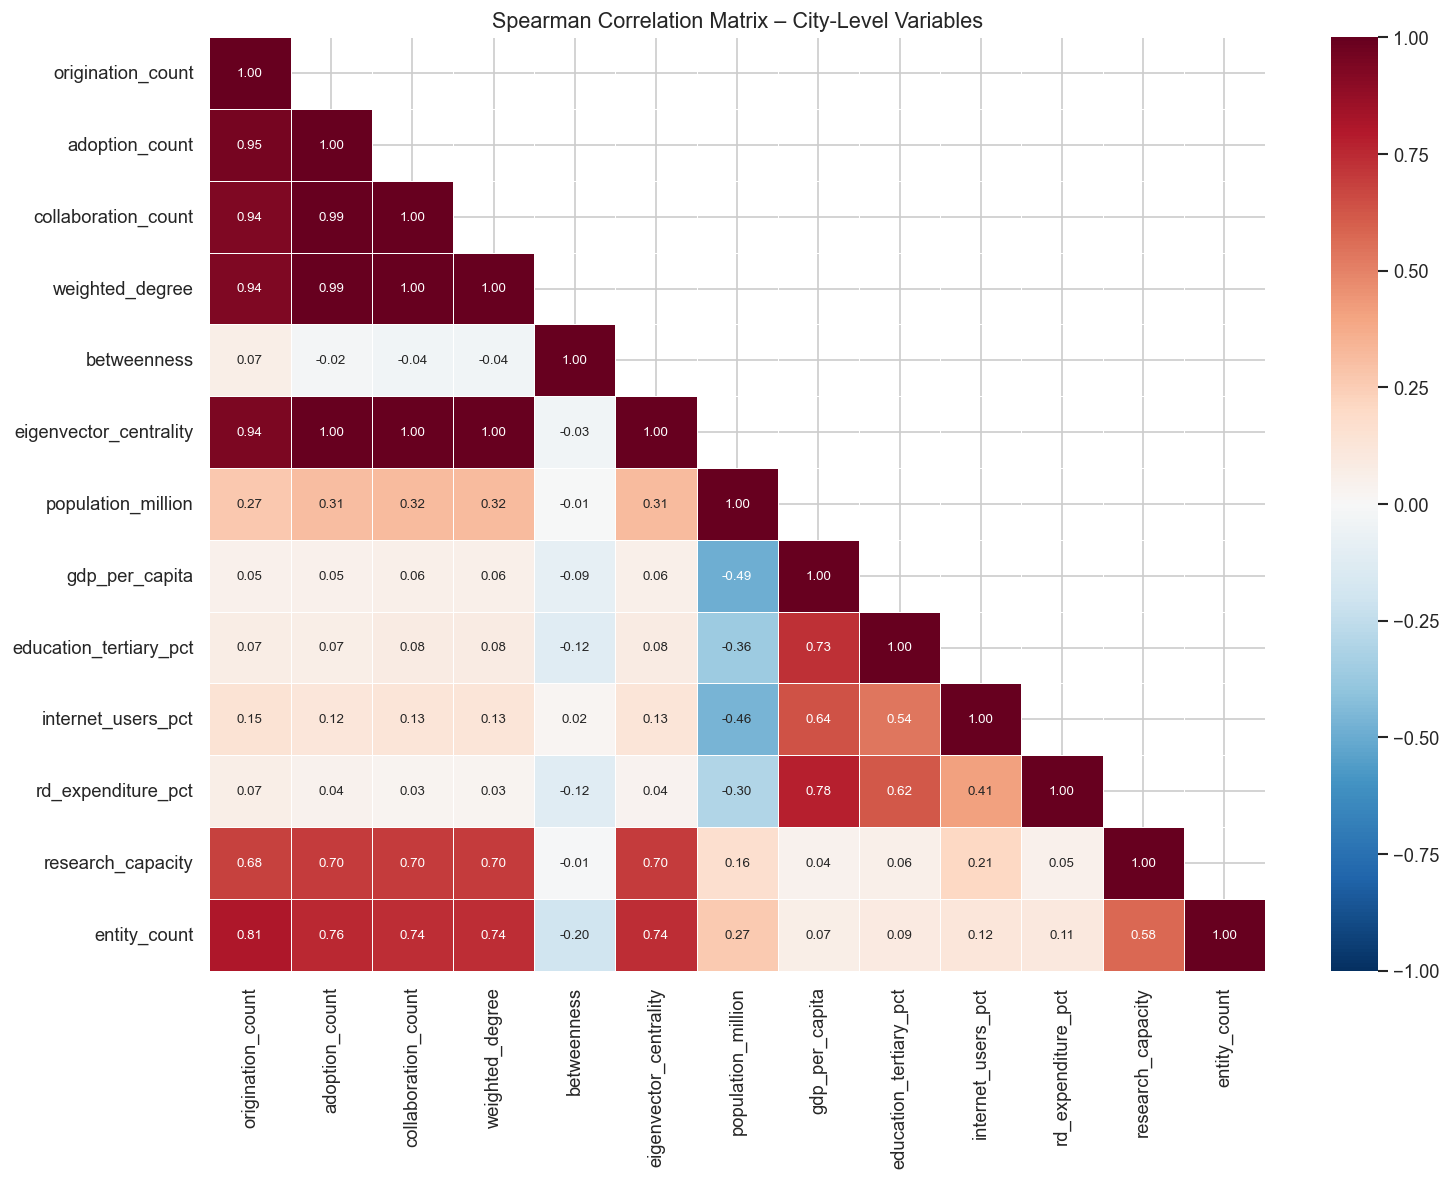

⚠️  Highly correlated pairs (|ρ| > 0.8):
   collaboration_count            ↔ weighted_degree                 ρ = +1.000
   collaboration_count            ↔ eigenvector_centrality          ρ = +1.000
   weighted_degree                ↔ eigenvector_centrality          ρ = +1.000
   adoption_count                 ↔ eigenvector_centrality          ρ = +0.996
   adoption_count                 ↔ collaboration_count             ρ = +0.994
   adoption_count                 ↔ weighted_degree                 ρ = +0.994
   origination_count              ↔ adoption_count                  ρ = +0.954
   origination_count              ↔ eigenvector_centrality          ρ = +0.941
   origination_count              ↔ collaboration_count             ρ = +0.937
   origination_count              ↔ weighted_degree                 ρ = +0.937
   origination_count              ↔ entity_count                    ρ = +0.812


In [9]:
# Correlation heatmap for key numeric variables
corr_cols = [
    'origination_count', 'adoption_count', 'collaboration_count',
    'weighted_degree', 'betweenness', 'eigenvector_centrality',
    'population_million', 'gdp_per_capita',
    'education_tertiary_pct', 'internet_users_pct',
    'rd_expenditure_pct', 'research_capacity',
    'entity_count',
]

corr_matrix = city_attr[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8}, linewidths=0.5)
ax.set_title('Spearman Correlation Matrix – City-Level Variables', fontsize=13)
plt.tight_layout()
plt.show()

# Flag high correlations (|r| > 0.8)
high_corr = []
for i in range(len(corr_cols)):
    for j in range(i+1, len(corr_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.8:
            high_corr.append((corr_cols[i], corr_cols[j], round(r, 3)))

if high_corr:
    print('⚠️  Highly correlated pairs (|ρ| > 0.8):')
    for a, b, r in sorted(high_corr, key=lambda x: -abs(x[2])):
        print(f'   {a:30s} ↔ {b:30s}  ρ = {r:+.3f}')
else:
    print('No highly correlated pairs (|ρ| > 0.8) found.')

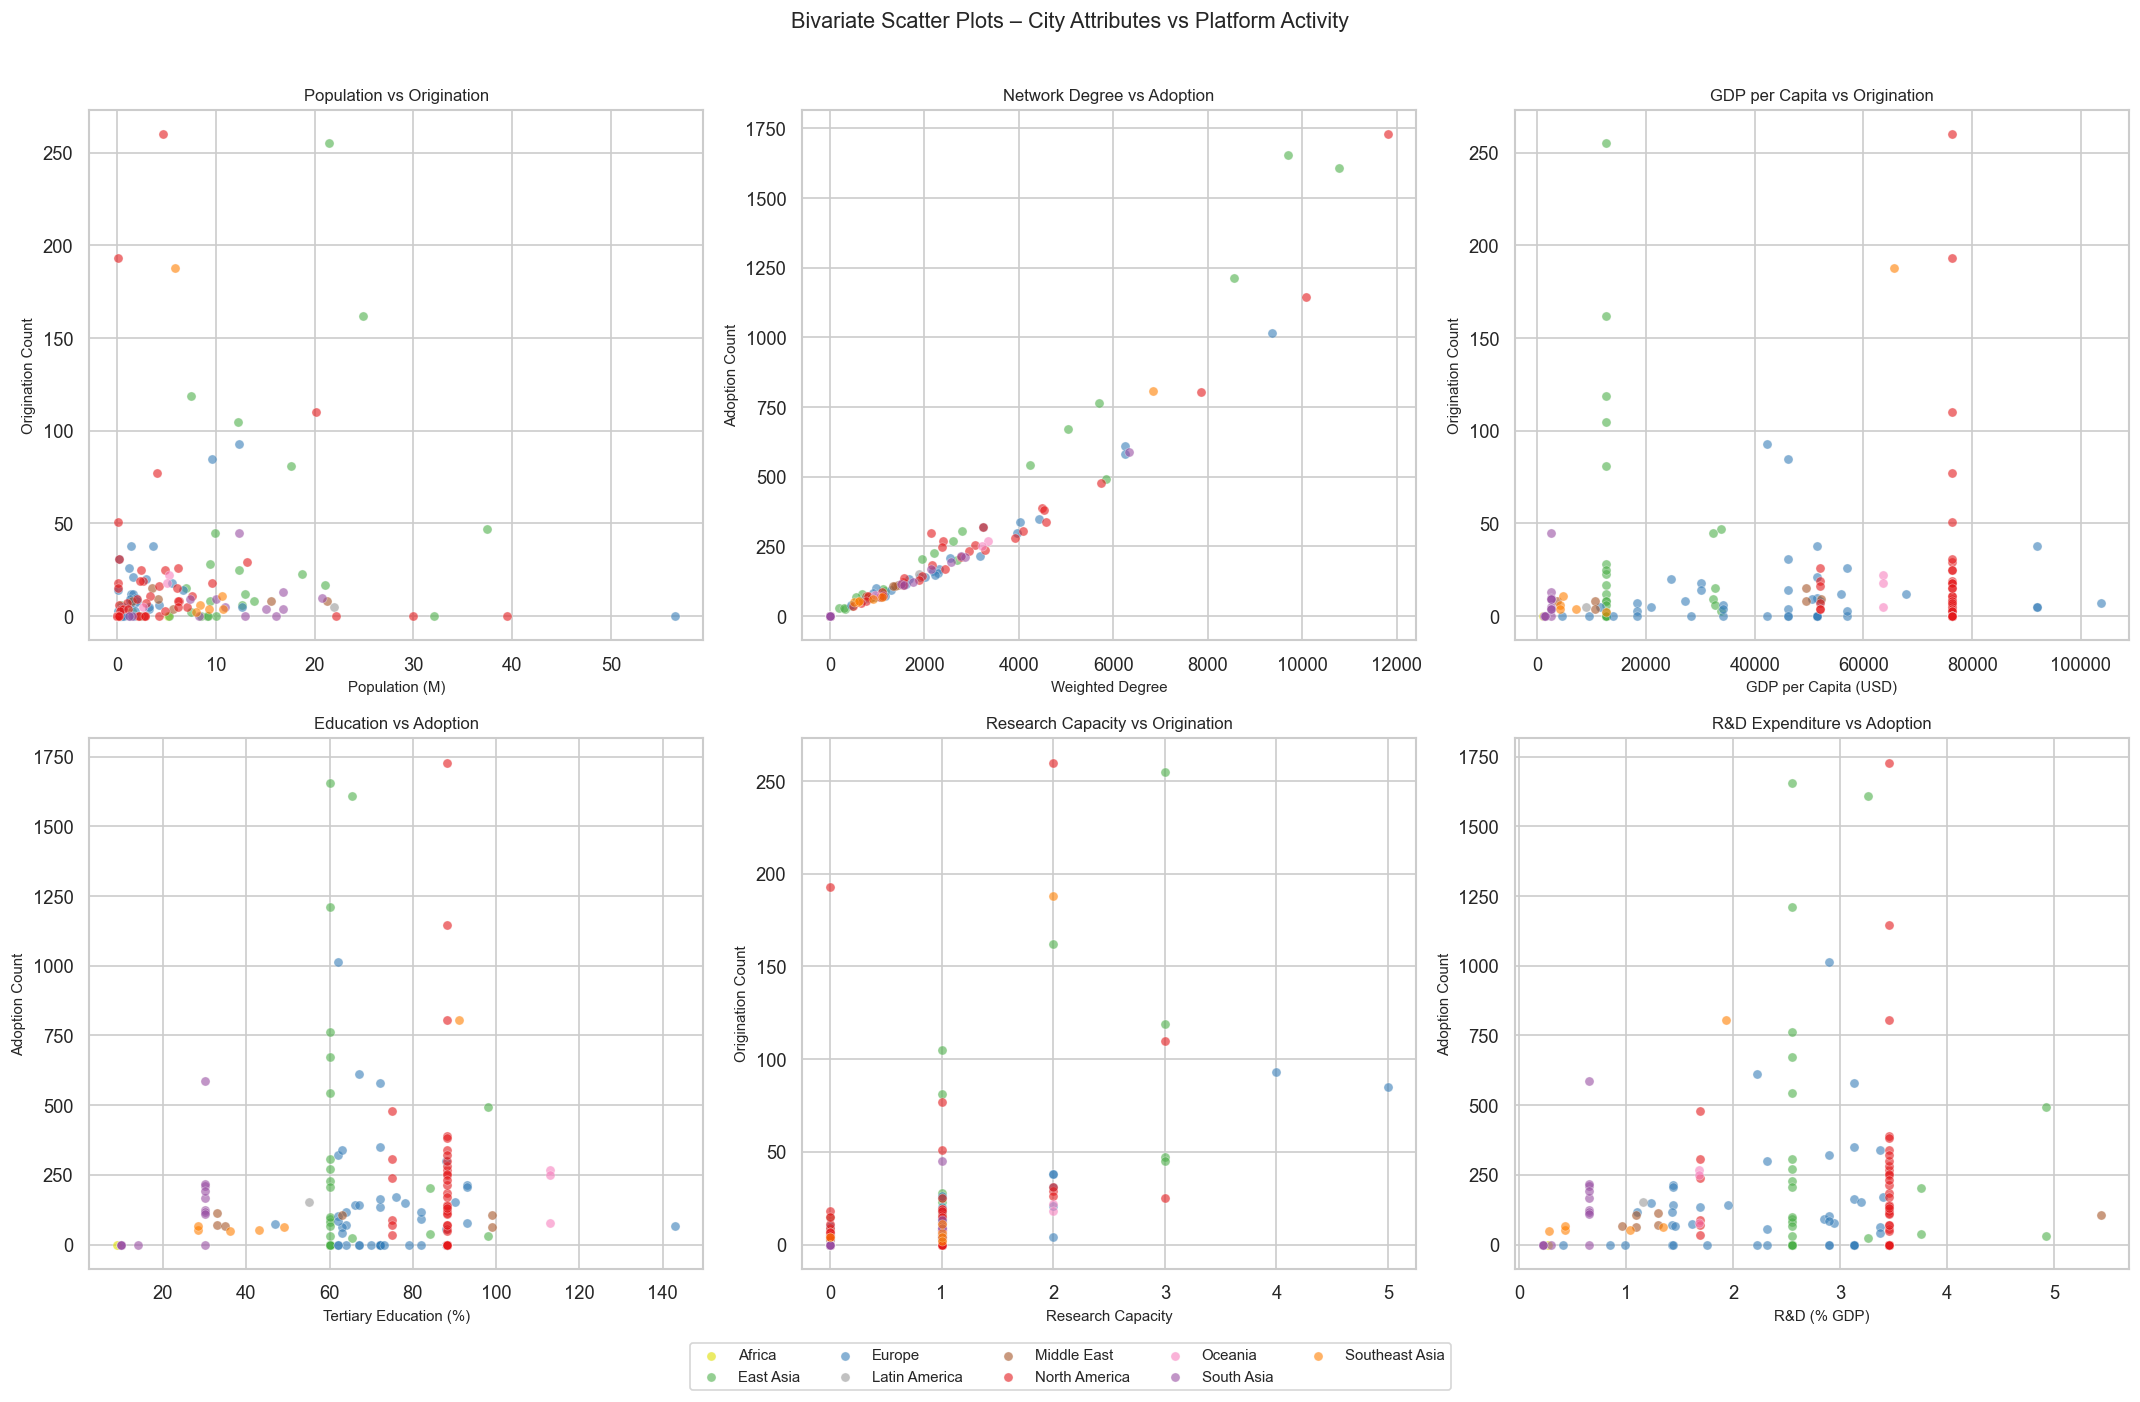

In [10]:
# Key scatter plots
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

scatter_pairs = [
    ('population_million', 'origination_count',
     'Population vs Origination', 'Population (M)', 'Origination Count'),
    ('weighted_degree', 'adoption_count',
     'Network Degree vs Adoption', 'Weighted Degree', 'Adoption Count'),
    ('gdp_per_capita', 'origination_count',
     'GDP per Capita vs Origination', 'GDP per Capita (USD)', 'Origination Count'),
    ('education_tertiary_pct', 'adoption_count',
     'Education vs Adoption', 'Tertiary Education (%)', 'Adoption Count'),
    ('research_capacity', 'origination_count',
     'Research Capacity vs Origination', 'Research Capacity', 'Origination Count'),
    ('rd_expenditure_pct', 'adoption_count',
     'R&D Expenditure vs Adoption', 'R&D (% GDP)', 'Adoption Count'),
]

# Assign colors by region
region_colors = {
    'North America': '#e41a1c', 'Europe': '#377eb8', 'East Asia': '#4daf4a',
    'South Asia': '#984ea3', 'Southeast Asia': '#ff7f00',
    'Middle East': '#a65628', 'Oceania': '#f781bf',
    'Latin America': '#999999', 'Africa': '#dede00',
}
city_attr['_color'] = city_attr['region'].map(region_colors)

for ax, (xc, yc, title, xlabel, ylabel) in zip(axes.flatten(), scatter_pairs):
    for region, grp in city_attr.groupby('region'):
        ax.scatter(grp[xc], grp[yc], c=region_colors.get(region, 'grey'),
                   label=region, alpha=0.6, s=30, edgecolors='white', linewidth=0.3)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)

# Single legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=9,
           bbox_to_anchor=(0.5, -0.04))

fig.suptitle('Bivariate Scatter Plots – City Attributes vs Platform Activity',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

city_attr.drop(columns='_color', inplace=True, errors='ignore')

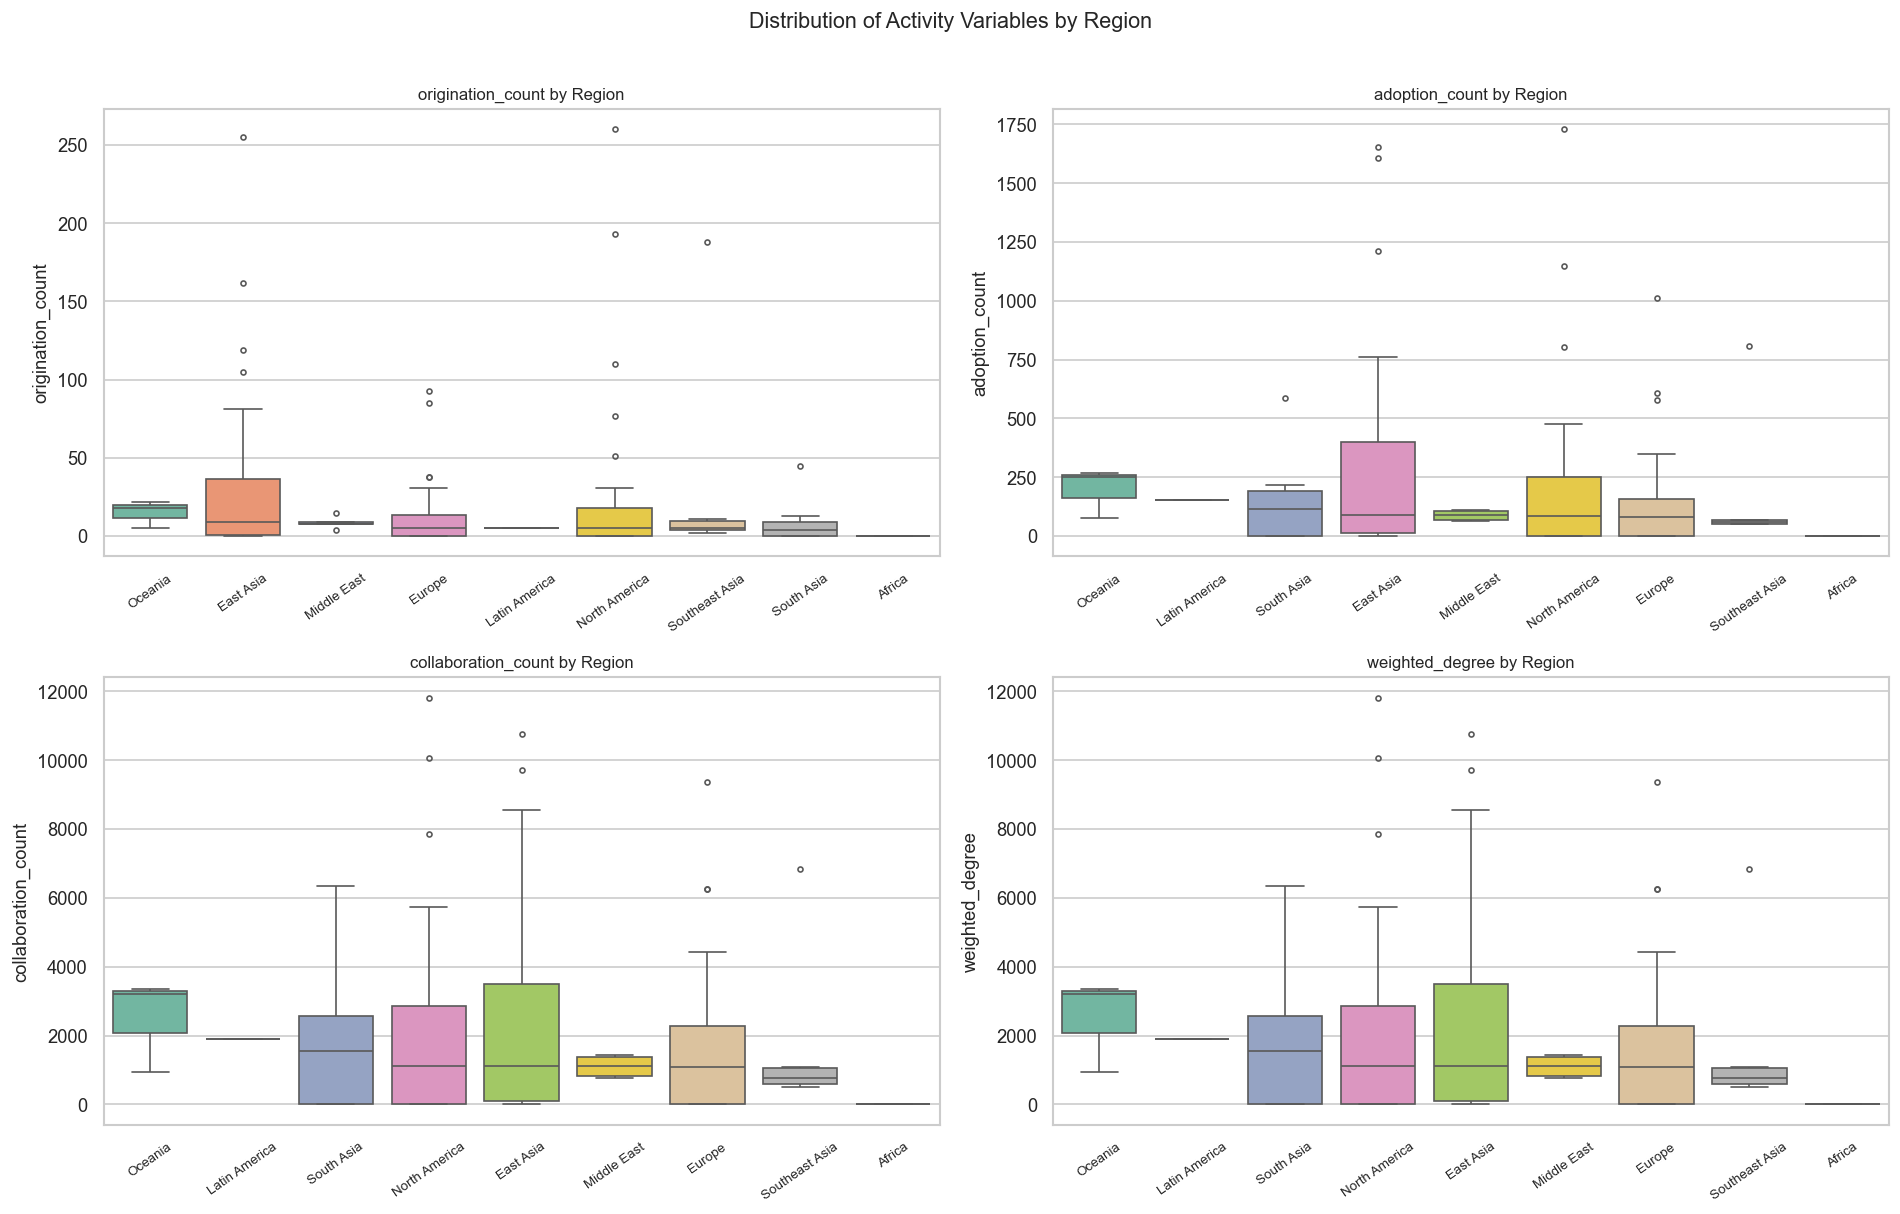

In [11]:
# Box plots: key activity variables by region
box_vars = ['origination_count', 'adoption_count', 'collaboration_count', 'weighted_degree']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, col in zip(axes.flatten(), box_vars):
    order = city_attr.groupby('region')[col].median().sort_values(ascending=False).index
    sns.boxplot(data=city_attr, x='region', y=col, order=order, ax=ax,
                palette='Set2', fliersize=3)
    ax.set_title(f'{col} by Region', fontsize=10)
    ax.tick_params(axis='x', rotation=35, labelsize=8)
    ax.set_xlabel('')

plt.suptitle('Distribution of Activity Variables by Region', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 8d – Spatial Distribution & Geographic Patterns

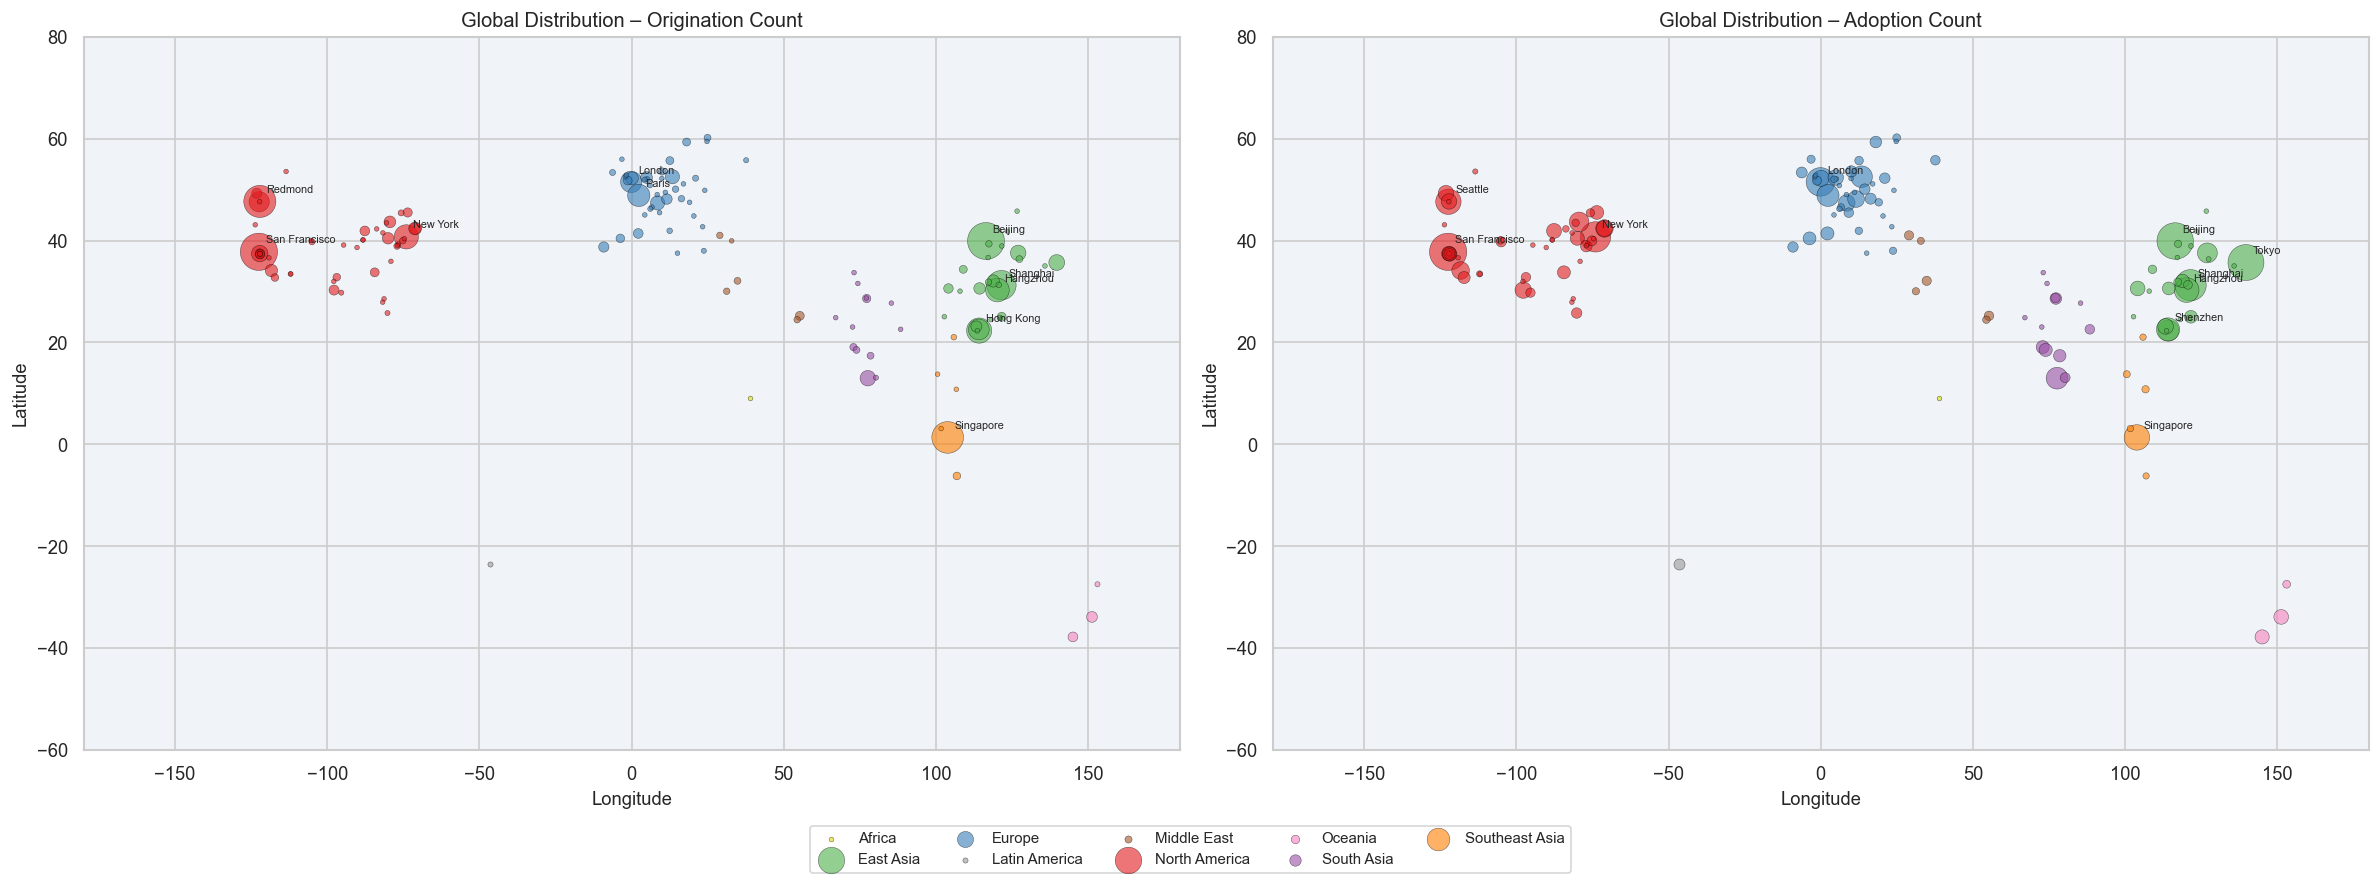

In [12]:
# Global scatter-map: bubble size = origination_count, color = region
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for ax, (size_col, title) in zip(axes, [
    ('origination_count', 'Origination Count'),
    ('adoption_count', 'Adoption Count'),
]):
    # Draw a simple world outline
    ax.set_facecolor('#f0f4f8')
    ax.set_xlim(-180, 180)
    ax.set_ylim(-60, 80)

    sizes = city_attr[size_col].fillna(0)
    sizes_scaled = (sizes / sizes.max() * 500).clip(lower=8)

    for region, grp in city_attr.groupby('region'):
        ax.scatter(grp['lon'], grp['lat'],
                   s=sizes_scaled.loc[grp.index],
                   c=region_colors.get(region, 'grey'),
                   alpha=0.6, edgecolors='black', linewidth=0.3,
                   label=region)

    # Label top 10 cities
    top10 = city_attr.nlargest(10, size_col)
    for _, row in top10.iterrows():
        ax.annotate(row['city'], (row['lon'], row['lat']),
                    fontsize=6.5, ha='left', va='bottom',
                    xytext=(4, 4), textcoords='offset points')

    ax.set_title(f'Global Distribution – {title}', fontsize=12)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=9,
           bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.show()

Regional Summary:


,n_cities,total_origination,total_adoption,total_collaboration,mean_gdp,mean_education
region,,,,,,
North America,51,1042.0,9476.0,99948.0,73477.1,86.6
East Asia,27,976.0,8616.0,66851.0,17213.8,65.0
Europe,42,511.0,5941.0,70334.0,44188.9,74.0
Southeast Asia,6,215.0,1093.0,10570.0,16398.7,46.0
South Asia,13,99.0,1725.0,21491.0,2162.4,24.2
Middle East,6,52.0,529.0,6578.0,29342.2,60.3
Oceania,3,45.0,595.0,7521.0,63530.0,113.0
Latin America,1,5.0,152.0,1890.0,8920.0,55.0
Africa,1,0.0,0.0,0.0,1020.0,9.0


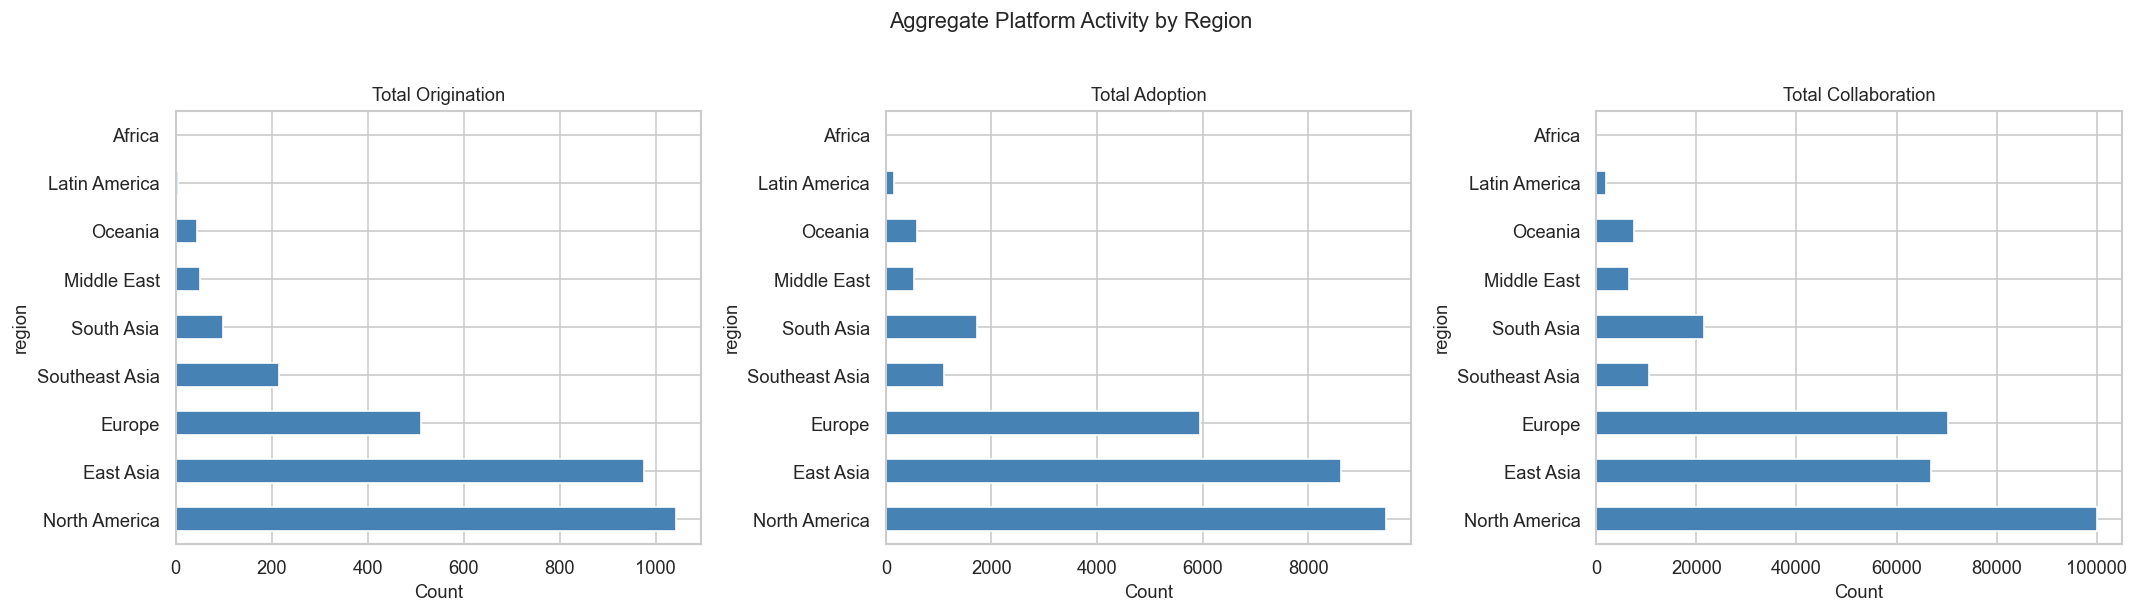

In [13]:
# Regional summary: aggregate activity
region_summary = city_attr.groupby('region').agg(
    n_cities=('city', 'count'),
    total_origination=('origination_count', 'sum'),
    total_adoption=('adoption_count', 'sum'),
    total_collaboration=('collaboration_count', 'sum'),
    mean_gdp=('gdp_per_capita', 'mean'),
    mean_education=('education_tertiary_pct', 'mean'),
).sort_values('total_origination', ascending=False)

print('Regional Summary:')
display(region_summary.round(1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, title) in zip(axes, [
    ('total_origination', 'Total Origination'),
    ('total_adoption', 'Total Adoption'),
    ('total_collaboration', 'Total Collaboration'),
]):
    region_summary[col].plot.barh(ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Count')

plt.suptitle('Aggregate Platform Activity by Region', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Origination: Top-10 cities account for 53.3%, Top-20 for 69.7%
Adoption: Top-10 cities account for 40.6%, Top-20 for 57.4%


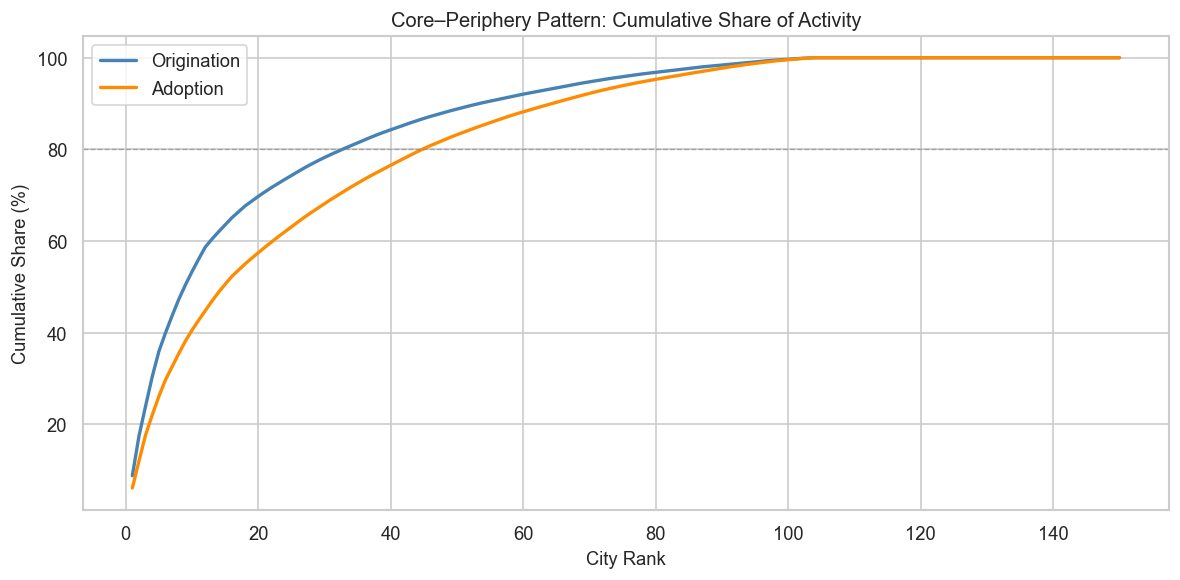

In [14]:
# Core-periphery pattern: cumulative share of origination/adoption
for col, label in [('origination_count', 'Origination'), ('adoption_count', 'Adoption')]:
    sorted_vals = city_attr[col].sort_values(ascending=False).values
    cumulative = np.cumsum(sorted_vals) / sorted_vals.sum() * 100
    top10_share = cumulative[9] if len(cumulative) >= 10 else cumulative[-1]
    top20_share = cumulative[19] if len(cumulative) >= 20 else cumulative[-1]
    print(f'{label}: Top-10 cities account for {top10_share:.1f}%, '
          f'Top-20 for {top20_share:.1f}%')

fig, ax = plt.subplots(figsize=(10, 5))
for col, label, color in [
    ('origination_count', 'Origination', 'steelblue'),
    ('adoption_count', 'Adoption', 'darkorange'),
]:
    sorted_vals = city_attr[col].sort_values(ascending=False).values
    cumulative = np.cumsum(sorted_vals) / sorted_vals.sum() * 100
    ax.plot(range(1, len(cumulative)+1), cumulative, label=label, color=color, lw=2)

ax.axhline(80, color='grey', ls='--', lw=0.8, alpha=0.6)
ax.set_xlabel('City Rank')
ax.set_ylabel('Cumulative Share (%)')
ax.set_title('Core–Periphery Pattern: Cumulative Share of Activity', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

---
## 8e – Temporal Trends

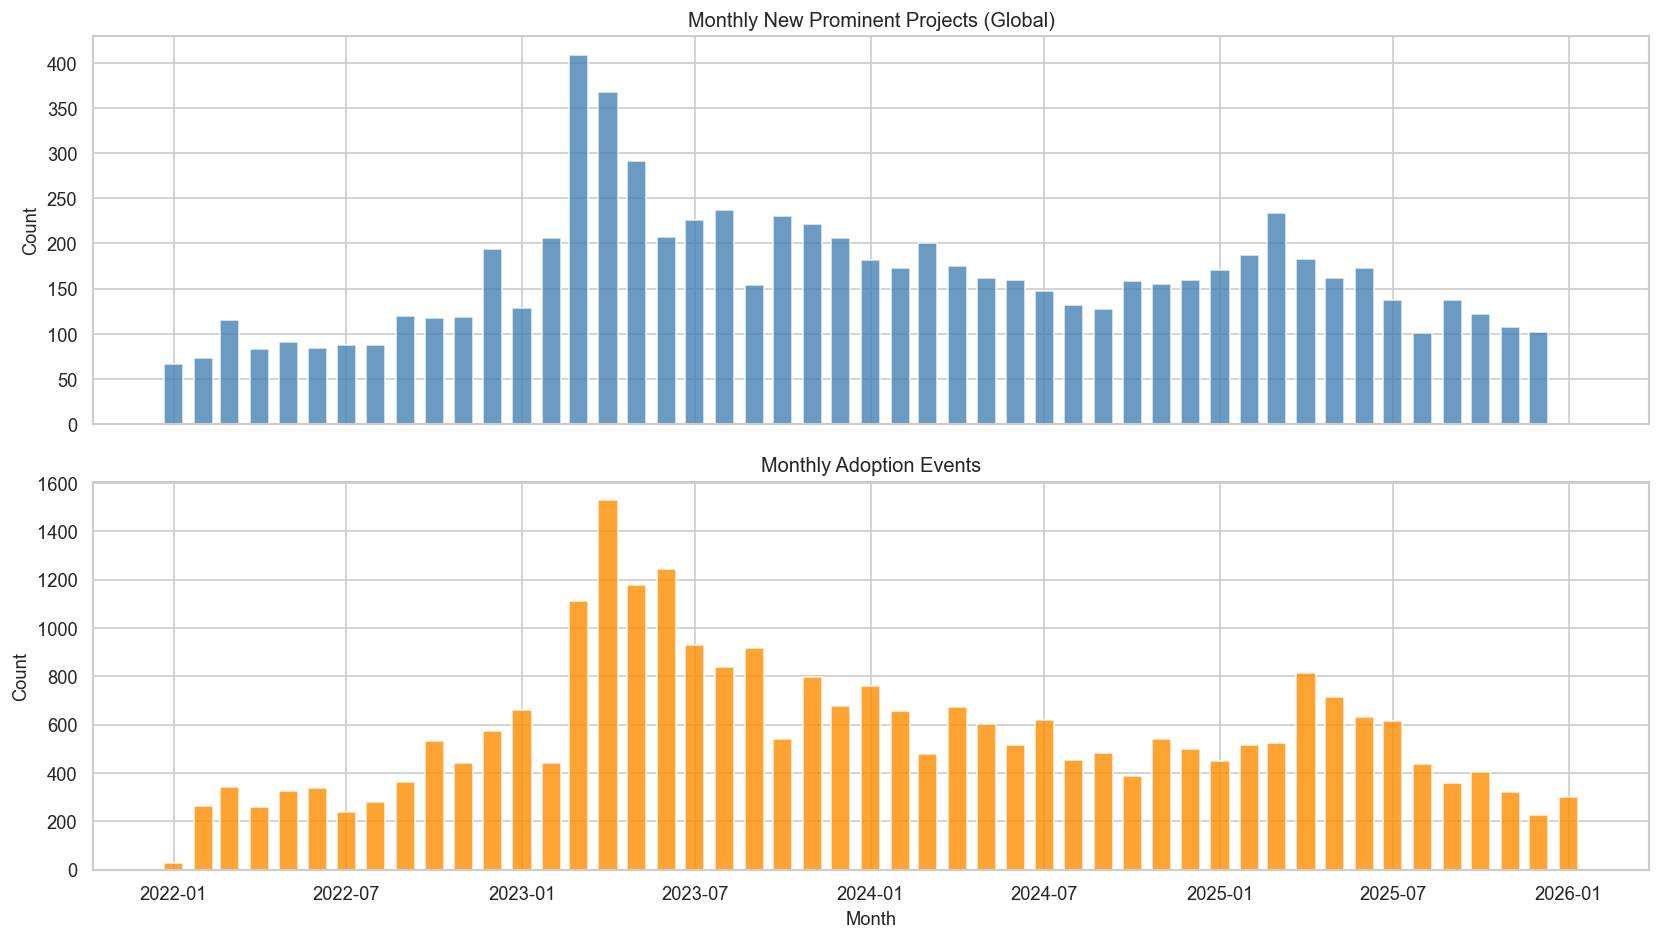

In [15]:
# Monthly time series: new projects and adoption events
def month_int_to_date(m):
    """Convert YYYYMM int to datetime."""
    y, mo = divmod(int(m), 100)
    return pd.Timestamp(y, mo, 1)

# New projects per month (global origin)
proj_monthly = (adoption.drop_duplicates('project_id')
                .groupby('global_origin_month').size()
                .rename('new_projects'))
proj_monthly.index = proj_monthly.index.map(month_int_to_date)

# Adoption events per month
adopt_monthly = (adoption.groupby('city_first_adoption_month').size()
                 .rename('adoption_events'))
adopt_monthly.index = adopt_monthly.index.map(month_int_to_date)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].bar(proj_monthly.index, proj_monthly.values, width=20,
            color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Monthly New Prominent Projects (Global)', fontsize=12)
axes[0].set_ylabel('Count')

axes[1].bar(adopt_monthly.index, adopt_monthly.values, width=20,
            color='darkorange', edgecolor='white', alpha=0.8)
axes[1].set_title('Monthly Adoption Events', fontsize=12)
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Month')

plt.tight_layout()
plt.show()

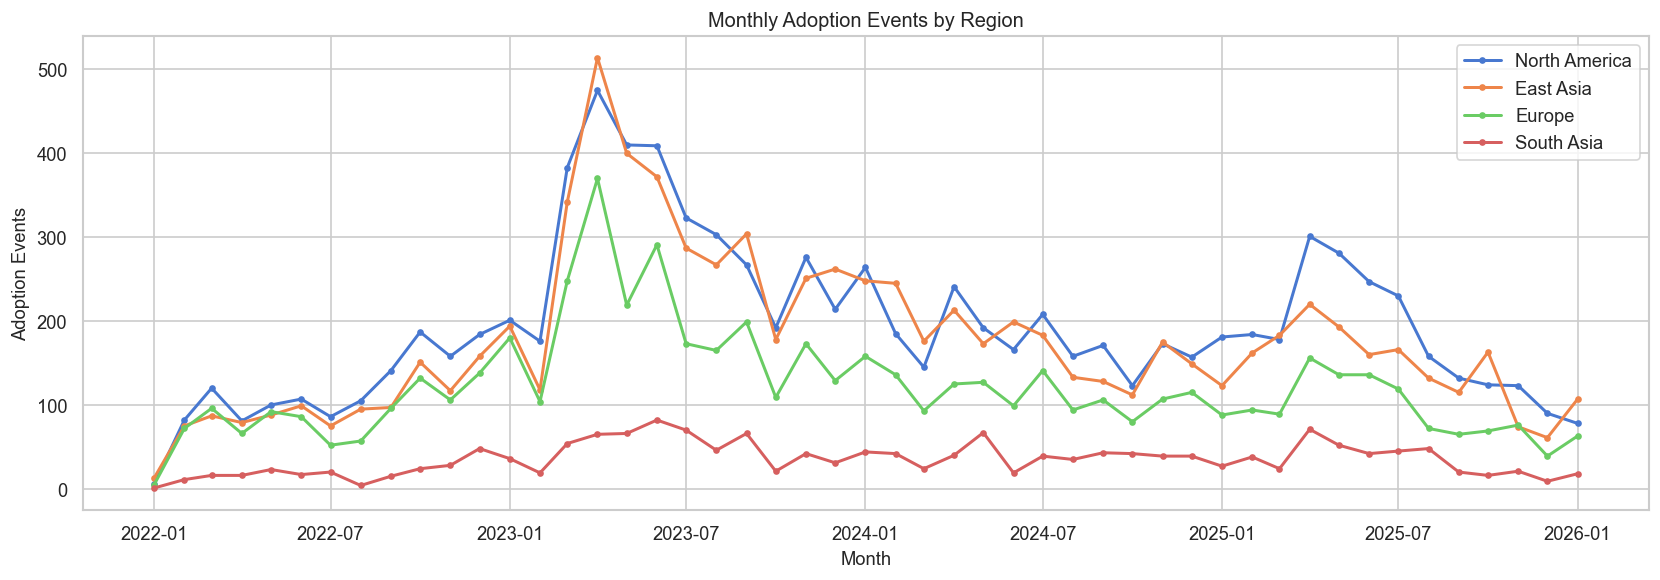

In [16]:
# Regional temporal trends
# Merge adoption events with city regions
adopt_region = adoption.merge(
    city_attr[['city', 'region']], on='city', how='left'
)

top_regions = ['North America', 'East Asia', 'Europe', 'South Asia']
region_monthly = (adopt_region[adopt_region['region'].isin(top_regions)]
                  .groupby(['city_first_adoption_month', 'region'])
                  .size().unstack(fill_value=0))
region_monthly.index = region_monthly.index.map(month_int_to_date)

fig, ax = plt.subplots(figsize=(14, 5))
for region in top_regions:
    if region in region_monthly.columns:
        ax.plot(region_monthly.index, region_monthly[region],
                label=region, lw=1.8, marker='o', markersize=3)

ax.set_title('Monthly Adoption Events by Region', fontsize=12)
ax.set_xlabel('Month')
ax.set_ylabel('Adoption Events')
ax.legend()
plt.tight_layout()
plt.show()

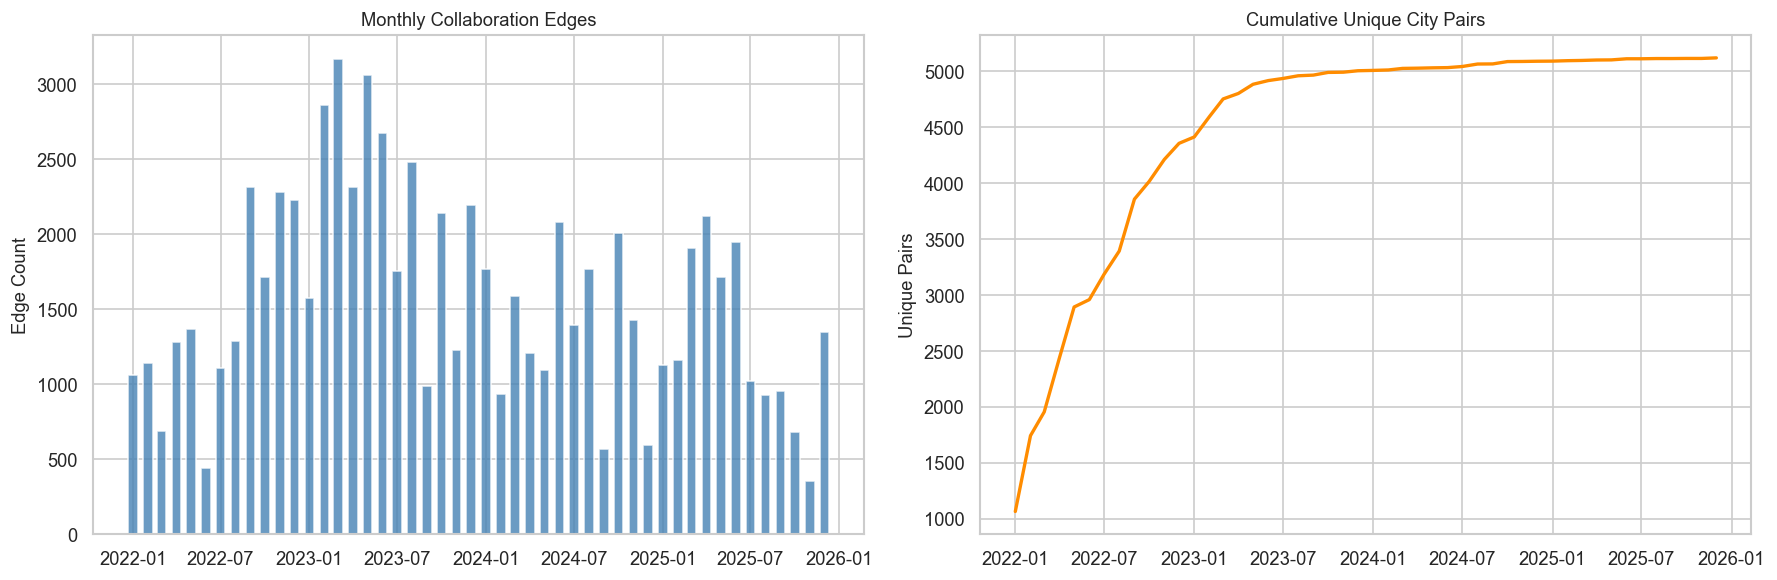

In [17]:
# Collaboration network growth over time
edge_ts = (edges_month.groupby('month')
           .agg(n_edges=('edge_weight', 'count'),
                unique_pairs=('source_city', 'count'))
           .reset_index())
edge_ts['date'] = edge_ts['month'].apply(month_int_to_date)

# Cumulative unique city pairs over time
seen_pairs = set()
cum_pairs = []
for _, row in edges_month.sort_values('month').iterrows():
    seen_pairs.add((row['source_city'], row['target_city']))
    cum_pairs.append((row['month'], len(seen_pairs)))
cum_df = pd.DataFrame(cum_pairs, columns=['month', 'cum_unique_pairs'])
cum_df = cum_df.groupby('month').last().reset_index()
cum_df['date'] = cum_df['month'].apply(month_int_to_date)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(edge_ts['date'], edge_ts['n_edges'], width=20,
            color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Monthly Collaboration Edges', fontsize=11)
axes[0].set_ylabel('Edge Count')

axes[1].plot(cum_df['date'], cum_df['cum_unique_pairs'],
             color='darkorange', lw=2)
axes[1].set_title('Cumulative Unique City Pairs', fontsize=11)
axes[1].set_ylabel('Unique Pairs')

plt.tight_layout()
plt.show()

---
## 8f – Network Preliminary Description

In [18]:
# Build the aggregate collaboration network
G = nx.Graph()
for _, row in edges_agg.iterrows():
    G.add_edge(row['source_city'], row['target_city'], weight=row['edge_weight'])

print('=== Network Summary ===')
print(f'Nodes (cities): {G.number_of_nodes()}')
print(f'Edges (city pairs): {G.number_of_edges()}')
print(f'Density: {nx.density(G):.4f}')
print(f'Connected components: {nx.number_connected_components(G)}')
if nx.is_connected(G):
    print(f'Diameter: {nx.diameter(G)}')
    print(f'Average shortest path: {nx.average_shortest_path_length(G):.2f}')
print(f'Average clustering coefficient: {nx.average_clustering(G, weight="weight"):.4f}')
print(f'Transitivity: {nx.transitivity(G):.4f}')

degrees = dict(G.degree(weight='weight'))
deg_vals = list(degrees.values())
print(f'\nDegree (weighted):')
print(f'  Mean: {np.mean(deg_vals):.1f}')
print(f'  Max:  {max(deg_vals):.0f} ({max(degrees, key=degrees.get)})')
print(f'  Min:  {min(deg_vals):.0f}')

=== Network Summary ===
Nodes (cities): 103
Edges (city pairs): 5118
Density: 0.9743
Connected components: 1
Diameter: 2
Average shortest path: 1.03


Average clustering coefficient: 0.0355
Transitivity: 0.9777

Degree (weighted):
  Mean: 2737.3
  Max:  11816 (San Francisco)
  Min:  185


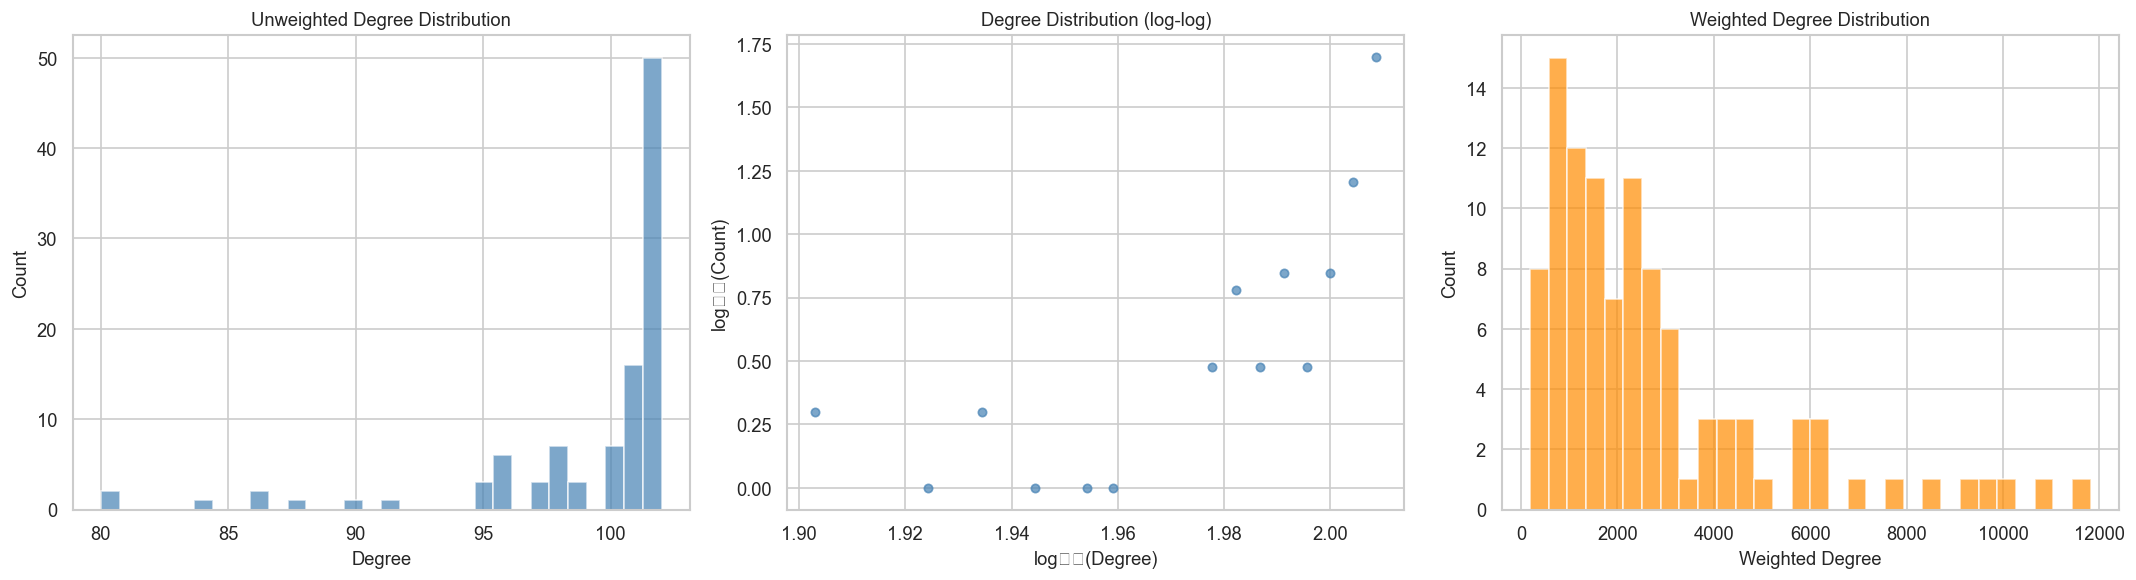

In [19]:
# Degree distribution
unweighted_deg = [d for _, d in G.degree()]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Unweighted degree distribution
axes[0].hist(unweighted_deg, bins=30, edgecolor='white', color='steelblue', alpha=0.7)
axes[0].set_title('Unweighted Degree Distribution', fontsize=11)
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Count')

# Log-log plot for power-law check
deg_counts = pd.Series(unweighted_deg).value_counts().sort_index()
axes[1].scatter(np.log10(deg_counts.index), np.log10(deg_counts.values),
                s=25, alpha=0.7, color='steelblue')
axes[1].set_title('Degree Distribution (log-log)', fontsize=11)
axes[1].set_xlabel('log₁₀(Degree)')
axes[1].set_ylabel('log₁₀(Count)')

# Weighted degree distribution
axes[2].hist(deg_vals, bins=30, edgecolor='white', color='darkorange', alpha=0.7)
axes[2].set_title('Weighted Degree Distribution', fontsize=11)
axes[2].set_xlabel('Weighted Degree')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

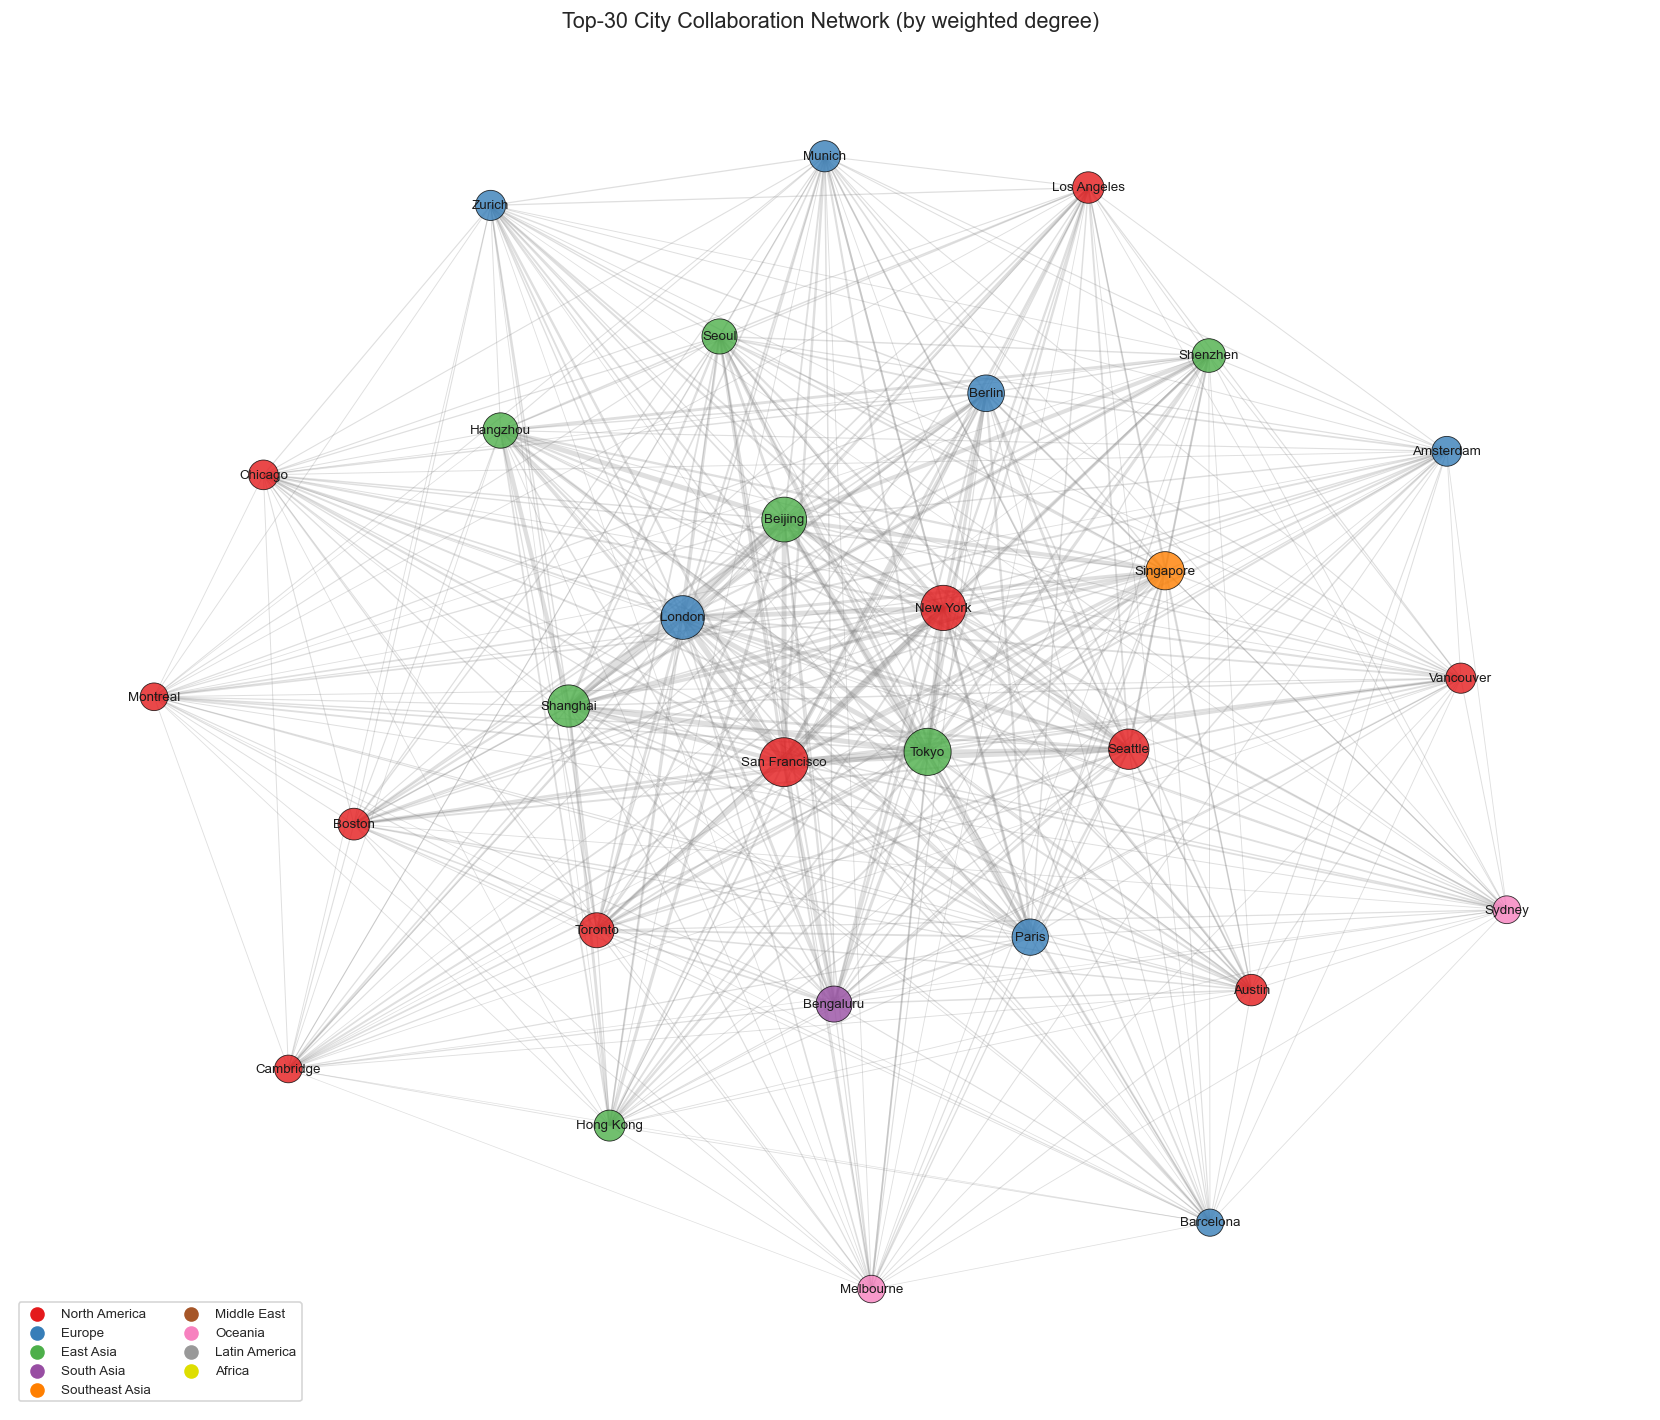

In [20]:
# Top-30 sub-network visualisation
top30_cities = city_attr.nlargest(30, 'weighted_degree')['city'].tolist()
H = G.subgraph(top30_cities).copy()

# Node sizes by weighted degree in subgraph
sub_deg = dict(H.degree(weight='weight'))
node_sizes = [sub_deg[n] / max(sub_deg.values()) * 800 + 60 for n in H.nodes()]

# Node colors by region
city_region = dict(zip(city_attr['city'], city_attr['region']))
node_colors = [region_colors.get(city_region.get(n, ''), 'grey') for n in H.nodes()]

# Edge widths
edge_weights = [H[u][v]['weight'] for u, v in H.edges()]
max_w = max(edge_weights) if edge_weights else 1
edge_widths = [w / max_w * 4 + 0.2 for w in edge_weights]

fig, ax = plt.subplots(figsize=(14, 12))
pos = nx.spring_layout(H, weight='weight', seed=42, k=1.5)

nx.draw_networkx_edges(H, pos, ax=ax, width=edge_widths, alpha=0.25, edge_color='grey')
nx.draw_networkx_nodes(H, pos, ax=ax, node_size=node_sizes,
                       node_color=node_colors, edgecolors='black', linewidths=0.5, alpha=0.8)
nx.draw_networkx_labels(H, pos, ax=ax, font_size=8)

# Legend
for region, color in region_colors.items():
    ax.scatter([], [], c=color, s=60, label=region)
ax.legend(loc='lower left', fontsize=8, ncol=2)
ax.set_title('Top-30 City Collaboration Network (by weighted degree)', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

In [21]:
# Top 15 cities by centrality metrics
betw = nx.betweenness_centrality(G, weight='weight')
try:
    eig = nx.eigenvector_centrality(G, weight='weight', max_iter=500)
except nx.PowerIterationFailedConvergence:
    eig = {n: 0 for n in G.nodes()}

centrality_df = pd.DataFrame({
    'city': list(G.nodes()),
    'degree': [G.degree(n) for n in G.nodes()],
    'weighted_degree': [G.degree(n, weight='weight') for n in G.nodes()],
    'betweenness': [betw[n] for n in G.nodes()],
    'eigenvector': [eig[n] for n in G.nodes()],
}).sort_values('weighted_degree', ascending=False)

print('Top 15 cities by network centrality:')
display(centrality_df.head(15).round(4))

Top 15 cities by network centrality:


,city,degree,weighted_degree,betweenness,eigenvector
3,San Francisco,102,11816,0.0,0.3111
4,Tokyo,102,10772,0.0,0.2910
2,New York,102,10075,0.0,0.2673
0,Beijing,102,9707,0.0,0.2642
5,London,102,9355,0.0,0.2488
1,Shanghai,102,8552,0.0,0.2354
6,Seattle,102,7848,0.0,0.2117
9,Singapore,102,6843,0.0,0.1878
11,Bengaluru,102,6332,0.0,0.1670
10,Berlin,102,6251,0.0,0.1690


---
## 8g – Implications for Subsequent Modelling

In [22]:
# Summary of EDA findings and modelling implications

print('=' * 70)
print('EDA SUMMARY & MODELLING IMPLICATIONS')
print('=' * 70)

print('''
1. DATA QUALITY
   - 150 cities, 26 variables, 103 cities with adoption events
   - avg_lag and median_lag have 46 NaN values (cities with no adoption)
   - No other missing values in city_attributes
   - 7,870 unique prominent projects across 103 adopting cities

2. DISTRIBUTION FINDINGS
   - origination_count, adoption_count, collaboration_count, weighted_degree
     are heavily right-skewed → log1p transform recommended for regression
   - population_million also right-skewed → log transform
   - K-means input must be standardised (z-score) after any transforms
   - education_tertiary_pct, internet_users_pct more symmetric — no transform

3. CORRELATION & COLLINEARITY
   - origination_count ↔ adoption_count: very high correlation
   - collaboration_count ↔ weighted_degree: essentially identical
     → Keep only weighted_degree for K-means / XGBoost to avoid redundancy
   - entity_count strongly correlated with all activity variables
     → entity_count is a proxy for developer base, use as control

4. SPATIAL PATTERNS
   - Clear core–periphery structure:
     Top-10 cities dominate origination and adoption
   - North America and East Asia lead in all activity metrics
   - Europe has many cities but moderate per-city activity
   - South Asia, Middle East, Africa relatively peripheral

5. TEMPORAL PATTERNS
   - Strong growth trend 2022–2024, reflecting AI boom
   - Possible seasonality (slight dips in December/January)
   - Network densification over time

6. NETWORK STRUCTURE
   - Dense network with high transitivity
   - Degree distribution right-skewed (hub-and-spoke pattern)
   - San Francisco, Beijing, Shanghai are top hubs
   - Network is connected → suitable for GraphSAGE

7. ADOPTION LAG LIMITATION
   - Current lag values are only 0 (originator) or 1 (contributor)
   - This is due to the approximation in step5 (contributors assigned
     creation_month + 1)
   - For richer adoption-lag regression, consider using per-commit
     timestamps or event-level data to compute finer-grained lags
   - Alternatively, model adoption as binary (adopted vs not adopted
     by time t) rather than continuous lag
''')

print('VARIABLE SELECTION RECOMMENDATIONS:')
print('-' * 50)
print('''
For K-means (city roles):
  - origination_rate_pop, adoption_rate_pop, collaboration_rate_pop
  - weighted_degree (normalised), betweenness, eigenvector_centrality
  - All standardised (z-score) after log1p transform where needed

For Adoption-lag regression (RQ2):
  - DV: binary adopted / not_adopted (or use lag = 0/1 as ordinal)
  - IVs: weighted_degree, research_capacity, gdp_per_capita,
         education_tertiary_pct, internet_users_pct, rd_expenditure_pct
  - Consider project fixed effects or project controls

For XGBoost (feature importance):
  - Target: innovation cluster membership OR fast-adopter flag
  - Features: all city attributes + network centrality
  - SHAP for interpretation

For GraphSAGE (next-adopter prediction):
  - Graph: city_collaboration_edges_monthly
  - Node features: city_attributes (numeric columns)
  - Labels: binary — did city adopt any new project in month t+1?
  - Network is connected and dense enough for GNN training
''')

EDA SUMMARY & MODELLING IMPLICATIONS

1. DATA QUALITY
   - 150 cities, 26 variables, 103 cities with adoption events
   - avg_lag and median_lag have 46 NaN values (cities with no adoption)
   - No other missing values in city_attributes
   - 7,870 unique prominent projects across 103 adopting cities

2. DISTRIBUTION FINDINGS
   - origination_count, adoption_count, collaboration_count, weighted_degree
     are heavily right-skewed → log1p transform recommended for regression
   - population_million also right-skewed → log transform
   - K-means input must be standardised (z-score) after any transforms
   - education_tertiary_pct, internet_users_pct more symmetric — no transform

3. CORRELATION & COLLINEARITY
   - origination_count ↔ adoption_count: very high correlation
   - collaboration_count ↔ weighted_degree: essentially identical
     → Keep only weighted_degree for K-means / XGBoost to avoid redundancy
   - entity_count strongly correlated with all activity variables
     → entit